# Test du VAE ré-entraîné avec augmentation par rotation

Compare `checkpoints/mnist.ckpt` (VAE d'origine, images "upright" uniquement) et
`checkpoints/mnist-v1.ckpt` (VAE ré-entraîné avec `RandomRotation` dans `numb_project/mnist_vae.py`)
sur leur capacité à reconstruire des images tournées à différents angles.

In [1]:
import os

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from numb_project.mnist_vae import VAE
from numb_project.data_module import rotate_image_batch
from numb_project.constants import VAE_CHECKPOINT_FILE, DEVICE

OLD_CKPT = os.path.join(os.path.dirname(VAE_CHECKPOINT_FILE), "mnist.ckpt")
NEW_CKPT = os.path.join(os.path.dirname(VAE_CHECKPOINT_FILE), "mnist-16D.ckpt")

vae_old = VAE.load_from_checkpoint(OLD_CKPT, map_location=DEVICE)
vae_new = VAE.load_from_checkpoint(NEW_CKPT, map_location=DEVICE)

for vae in (vae_old, vae_new):
    vae.eval()
    vae.freeze()

print("VAE ancien (sans rotation):", OLD_CKPT)
print("VAE nouveau (entraîné avec rotations):", NEW_CKPT)

VAE ancien (sans rotation): /home/lucasc/Projects/gwnumb/checkpoints/mnist.ckpt
VAE nouveau (entraîné avec rotations): /home/lucasc/Projects/gwnumb/checkpoints/mnist-16D.ckpt


/home/lucasc/.cache/pypoetry/virtualenvs/gwnumb-MdIKXIiF-py3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

image_batch, _ = next(iter(test_loader))
image_batch = image_batch.to(DEVICE)

print("image_batch shape:", image_batch.shape)

image_batch shape: torch.Size([64, 1, 28, 28])


angle=  0°: MSE ancien=0.00972  MSE nouveau=0.01234
angle= 20°: MSE ancien=0.01283  MSE nouveau=0.00834
angle= 40°: MSE ancien=0.02445  MSE nouveau=0.00827
angle= 60°: MSE ancien=0.03299  MSE nouveau=0.00845
angle= 80°: MSE ancien=0.03741  MSE nouveau=0.00813
angle=100°: MSE ancien=0.03795  MSE nouveau=0.00832
angle=120°: MSE ancien=0.03551  MSE nouveau=0.00836
angle=140°: MSE ancien=0.03492  MSE nouveau=0.00848
angle=160°: MSE ancien=0.02800  MSE nouveau=0.00838
angle=180°: MSE ancien=0.02958  MSE nouveau=0.01280
angle=200°: MSE ancien=0.02718  MSE nouveau=0.00837
angle=220°: MSE ancien=0.03262  MSE nouveau=0.00816
angle=240°: MSE ancien=0.03786  MSE nouveau=0.00820
angle=260°: MSE ancien=0.03876  MSE nouveau=0.00837
angle=280°: MSE ancien=0.03465  MSE nouveau=0.00854
angle=300°: MSE ancien=0.02840  MSE nouveau=0.00835
angle=320°: MSE ancien=0.02171  MSE nouveau=0.00840
angle=340°: MSE ancien=0.01208  MSE nouveau=0.00850


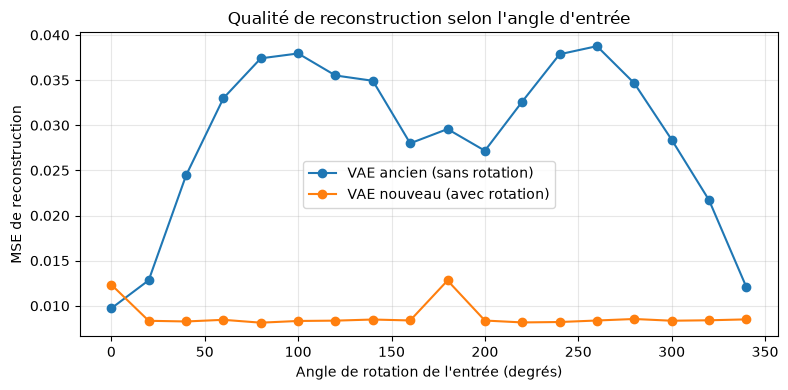

In [3]:
def reconstruct(vae: VAE, images: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        mu, _ = vae.encoder(images)
        return vae.decoder(mu)


# --- MSE de reconstruction en fonction de l'angle de rotation de l'entrée ---
angles = list(range(0, 360, 20))
mse_old, mse_new = [], []

for angle in angles:
    angle_deg = torch.full((image_batch.shape[0],), float(angle), device=image_batch.device)
    rotated = rotate_image_batch(image_batch, angle_deg)

    recon_old = reconstruct(vae_old, rotated)
    recon_new = reconstruct(vae_new, rotated)

    mse_old.append(F.mse_loss(recon_old, rotated).item())
    mse_new.append(F.mse_loss(recon_new, rotated).item())
    print(f"angle={angle:>3}°: MSE ancien={mse_old[-1]:.5f}  MSE nouveau={mse_new[-1]:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(angles, mse_old, marker="o", label="VAE ancien (sans rotation)")
plt.plot(angles, mse_new, marker="o", label="VAE nouveau (avec rotation)")
plt.xlabel("Angle de rotation de l'entrée (degrés)")
plt.ylabel("MSE de reconstruction")
plt.title("Qualité de reconstruction selon l'angle d'entrée")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

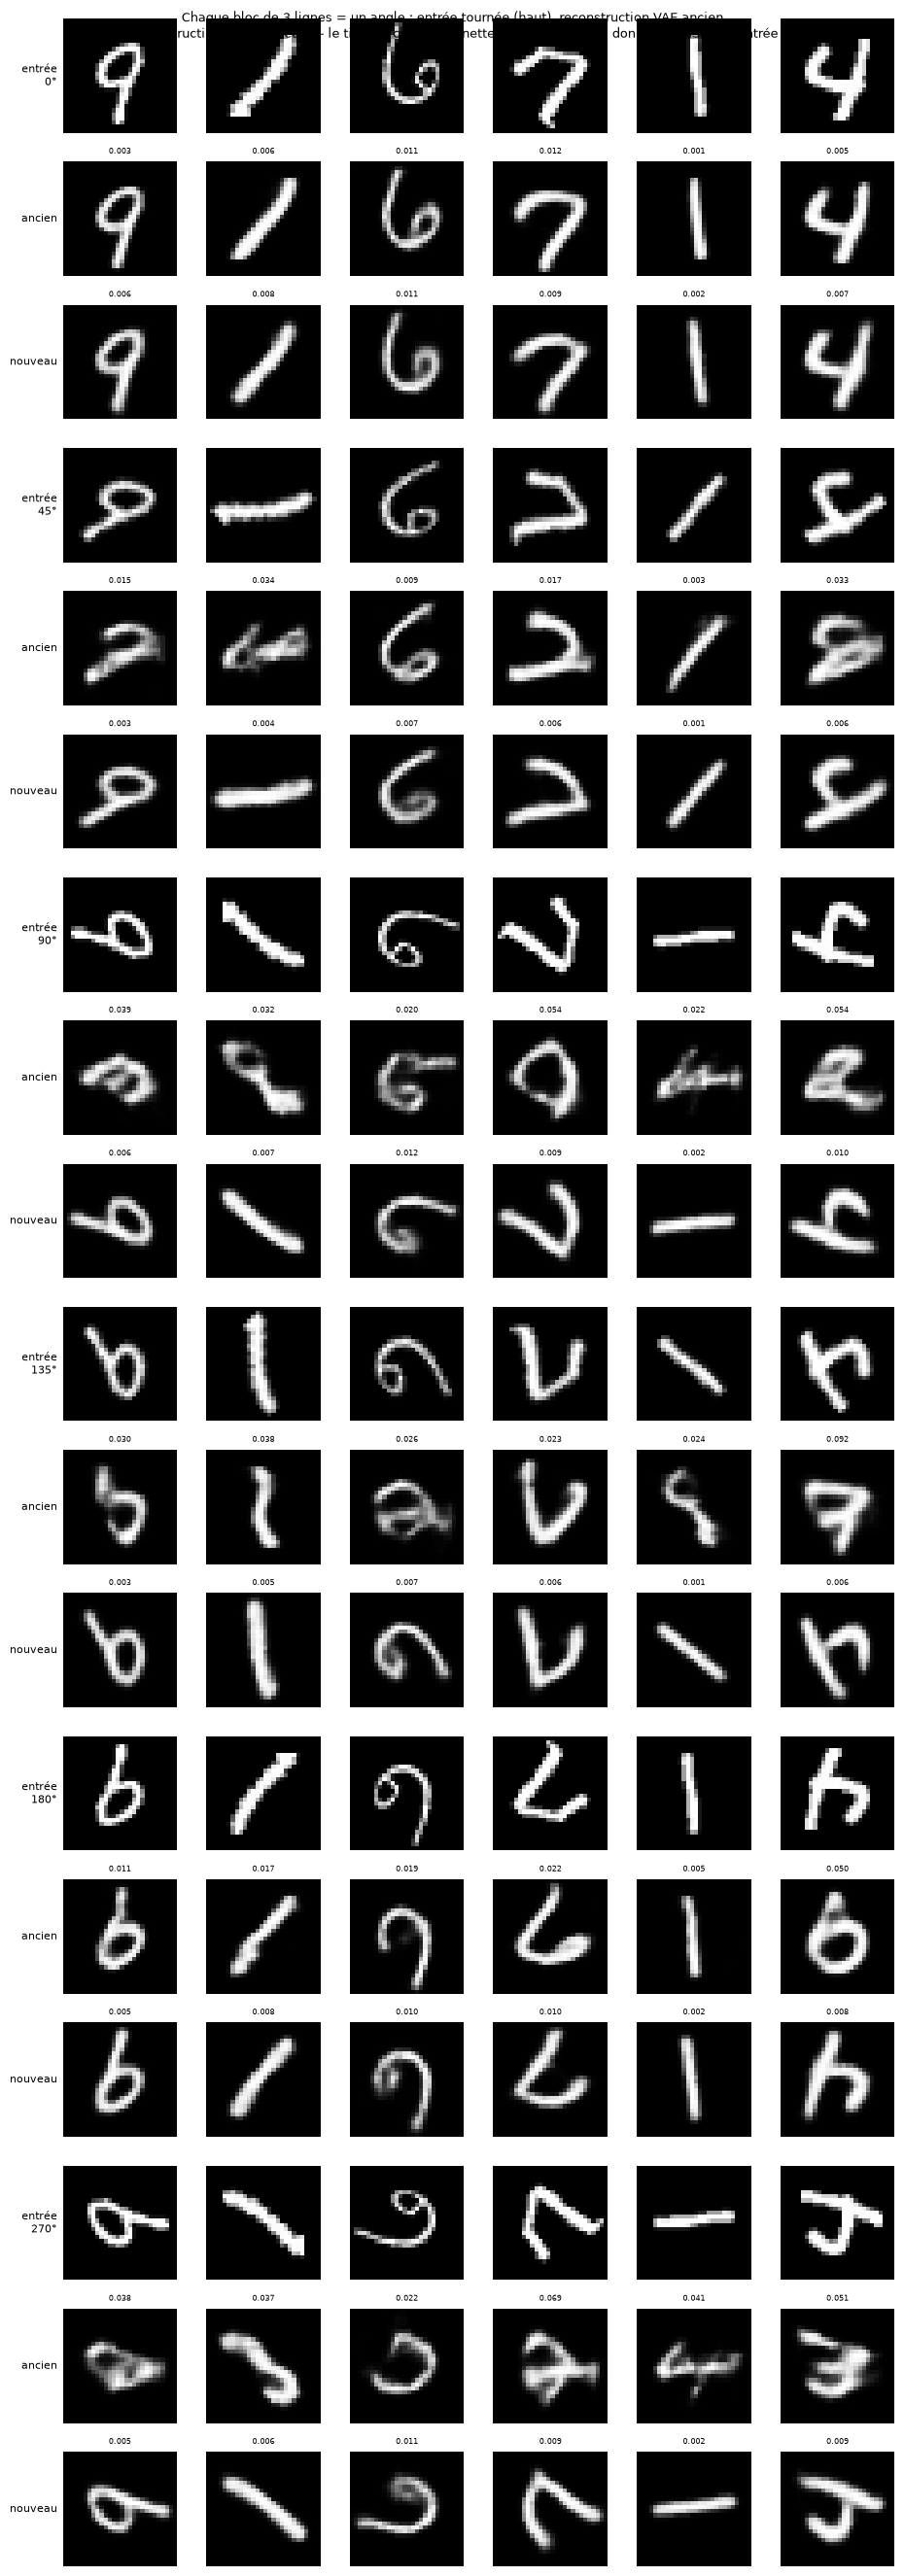

In [4]:
# --- Comparaison qualitative à quelques angles ---
# Pour chaque angle : l'image tournée en entrée, puis sa reconstruction par
# chaque VAE (avec le MSE par image affiché en titre), pour juger directement
# la qualité de chaque reconstruction face à ce qu'elle devait reproduire.
angles_to_show = [0, 45, 90, 135, 180, 270]
n_show = min(6, image_batch.shape[0])
n_groups = len(angles_to_show)
n_rows = 3 * n_groups  # par angle : entrée tournée / reconstruction ancien / reconstruction nouveau

fig, axes = plt.subplots(n_rows, n_show, figsize=(n_show * 1.6, 1.5 * n_rows))
fig.suptitle(
    "Chaque bloc de 3 lignes = un angle : entrée tournée (haut), reconstruction VAE ancien,\n"
    "reconstruction VAE nouveau — le titre de chaque vignette de reconstruction donne son MSE vs l'entrée",
    fontsize=9,
)


def show_row(row: int, images: torch.Tensor, label: str, titles: list[str] | None = None) -> None:
    for i in range(n_show):
        ax = axes[row, i]
        ax.imshow(images[i, 0].detach().cpu().numpy(), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if titles is not None:
            ax.set_title(titles[i], fontsize=6)
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, ha="right", va="center")


row = 0
for angle in angles_to_show:
    angle_deg = torch.full((image_batch.shape[0],), float(angle), device=image_batch.device)
    rotated = rotate_image_batch(image_batch, angle_deg)

    recon_old = reconstruct(vae_old, rotated)
    recon_new = reconstruct(vae_new, rotated)

    mse_old_per_img = [F.mse_loss(recon_old[i], rotated[i]).item() for i in range(n_show)]
    mse_new_per_img = [F.mse_loss(recon_new[i], rotated[i]).item() for i in range(n_show)]

    show_row(row, rotated, f"entrée\n{angle}°")
    show_row(row + 1, recon_old, "ancien", titles=[f"{m:.3f}" for m in mse_old_per_img])
    show_row(row + 2, recon_new, "nouveau", titles=[f"{m:.3f}" for m in mse_new_per_img])

    row += 3

plt.tight_layout()
plt.show()